# **UCI HAR - Contrastive SSL + Fine-tuning**

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model, backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [3]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [4]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []                                        # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')              # 공백 2개를 1개로
                row_clean = row_clean.strip()                   # 양쪽 공백 제거
                serie = row_clean.split(' ')                    # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array)                 # 시퀀스 추가

        X_signals.append(series_list)

    X_signals = np.array(X_signals)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

In [5]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

Model Building

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 1. 데이터 증강 (Augmentation)
# 동일 샘플의 서로 다른 'View'를 생성
def augmentation(x):
    # 가우시안 노이즈 추가 및 스케일링
    noise = torch.randn_like(x) * 0.05
    scaling = x * (torch.randn(1) * 0.1 + 1.0)
    return scaling + noise

# 2. CNN Encoder (특징 추출기)
# 시계열 데이터의 특징을 추출하는 핵심 구조
class CNN_Encoder(nn.Module):
    def __init__(self):
        super(CNN_Encoder, self).__init__()
        # 입력 채널 9 (가속도/자이로 축), 출력 채널 128
        self.conv_block = nn.Sequential(
            nn.Conv1d(9, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # 글로벌 평균 풀링으로 고정 크기 벡터 출력
        )

    def forward(self, x):
        # x shape: (Batch, 128, 9) -> Conv1d를 위해 (Batch, 9, 128)로 변환
        x = x.transpose(1, 2)
        x = self.conv_block(x)
        return x.squeeze(-1) # (Batch, 128) 특징 벡터 반환

# 3. Contrastive SSL 모델
class ContrastiveCNN(nn.Module):
    def __init__(self, encoder):
        super(ContrastiveCNN, self).__init__()
        self.encoder = encoder
        # 특징 공간에서 대조를 수행
        self.projector = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return z

In [17]:
# ==========================================
# STEP 1: Contrastive SSL (Pre-training)
# ==========================================
encoder = CNN_Encoder()
ssl_model = ContrastiveCNN(encoder)
optimizer = optim.Adam(ssl_model.parameters(), lr=1e-3)

# NT-Xent Loss (유사도 기반 대조 손실)
def nt_xent_loss(z_i, z_j, temperature=0.5):
    # 두 변형
    z = torch.cat([z_i, z_j], dim=0)
    n = z.shape[0]

    # 유사도 계산
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(n, device=z.device).bool()
    sim = sim.masked_fill(mask, -9e15)

    # 정답 인덱스 생성 (i번째의 짝은 i+batch_size)
    batch_size = n // 2
    labels = torch.cat([torch.arange(batch_size, 2*batch_size),
                        torch.arange(batch_size)], dim=0).to(z.device)

    # Cross Entropy를 이용한 대조 손실 계산
    loss = F.cross_entropy(sim, labels)
    return loss

In [42]:
# ==========================================
# STEP 2: Fine-tuning (Downstream Task)
# ==========================================
class FineTuneCNN(nn.Module):
    def __init__(self, pretrained_encoder, num_classes=6):
        super(FineTuneCNN, self).__init__()
        self.encoder = pretrained_encoder
        # 사전 학습된 가중치를 보존하기 위해 초기에는 freeze 가능
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 고차원 특징 표현 추출
        h = self.encoder(x)
        # 실제 행동 분류 수행
        return self.classifier(h)

# SSL로 예습이 끝난 encoder를 주입하여 최종 모델 생성
final_model = FineTuneCNN(encoder)

In [23]:
# train_loader 내의 데이터 한 배치
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 그 중 첫 번째 데이터 하나만 sample_data로 지정
sample_data = images[:1].to(device)

# 학습 전 초기 벡터 저장
ssl_model.eval()
with torch.no_grad():
    initial_z = ssl_model(sample_data)

1. Contrastive SSL : 사전학습 (Pre-training)

In [24]:
# 하이퍼파라미터 설정
ssl_epochs = 30
learning_rate = 1e-3
temperature = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 및 옵티마이저 초기화
encoder = CNN_Encoder().to(device)
ssl_model = ContrastiveCNN(encoder).to(device)
optimizer = optim.Adam(ssl_model.parameters(), lr=learning_rate)

In [25]:
from torch.utils.data import DataLoader, TensorDataset

# 1. 데이터를 텐서 형태로 변환
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))

# 2. train_loader 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

for epoch in range(ssl_epochs):
    ssl_model.train()
    total_loss = 0

    for x_batch, _ in train_loader: # 라벨(_)은 사용하지 않음
        x_batch = x_batch.to(device)

        # 1. 두 가지 변형(Augmentation) 생성
        x_i = augmentation(x_batch)
        x_j = augmentation(x_batch)

        # 2. 특징 추출 및 투사(Projection)
        z_i = ssl_model(x_i)
        z_j = ssl_model(x_j)

        # 3. NT-Xent Loss 계산 (Positive는 가깝게, Negative는 멀게)
        loss = nt_xent_loss(z_i, z_j, temperature)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{ssl_epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/30], Loss: 1.1976
Epoch [2/30], Loss: 0.4321
Epoch [3/30], Loss: 0.3606
Epoch [4/30], Loss: 0.2919
Epoch [5/30], Loss: 0.3151
Epoch [6/30], Loss: 0.2730
Epoch [7/30], Loss: 0.2541
Epoch [8/30], Loss: 0.2396
Epoch [9/30], Loss: 0.2062
Epoch [10/30], Loss: 0.2045
Epoch [11/30], Loss: 0.2376
Epoch [12/30], Loss: 0.1954
Epoch [13/30], Loss: 0.2197
Epoch [14/30], Loss: 0.2200
Epoch [15/30], Loss: 0.1840
Epoch [16/30], Loss: 0.1734
Epoch [17/30], Loss: 0.1844
Epoch [18/30], Loss: 0.2241
Epoch [19/30], Loss: 0.2035
Epoch [20/30], Loss: 0.1701
Epoch [21/30], Loss: 0.1488
Epoch [22/30], Loss: 0.1732
Epoch [23/30], Loss: 0.1680
Epoch [24/30], Loss: 0.1562
Epoch [25/30], Loss: 0.1509
Epoch [26/30], Loss: 0.1705
Epoch [27/30], Loss: 0.1613
Epoch [28/30], Loss: 0.1508
Epoch [29/30], Loss: 0.1683
Epoch [30/30], Loss: 0.1591


In [26]:
# 학습 후 최종 벡터 저장
ssl_model.eval()
with torch.no_grad():
    final_z = ssl_model(sample_data)

print("\n================ 임베딩 변화 확인 ================")
print(f"초기 임베딩 첫 5개 값: {initial_z[0][:5].cpu().numpy()}")
print(f"최종 임베딩 첫 5개 값: {final_z[0][:5].cpu().numpy()}")


================ 임베딩 변화 확인 ================
초기 임베딩 첫 5개 값: [ 1.0731639   1.342123    0.62281454  0.48053765 -1.1762253 ]
최종 임베딩 첫 5개 값: [ 0.9344887   1.581807    1.1477242  -0.4411094   0.57548714]


In [27]:
# 두 벡터 사이의 유클리드 거리 계산 (얼마나 많이 변했는가)
distance = torch.norm(initial_z - final_z)
print(f"임베딩 이동 거리: {distance.item():.4f}")

임베딩 이동 거리: 12.9219


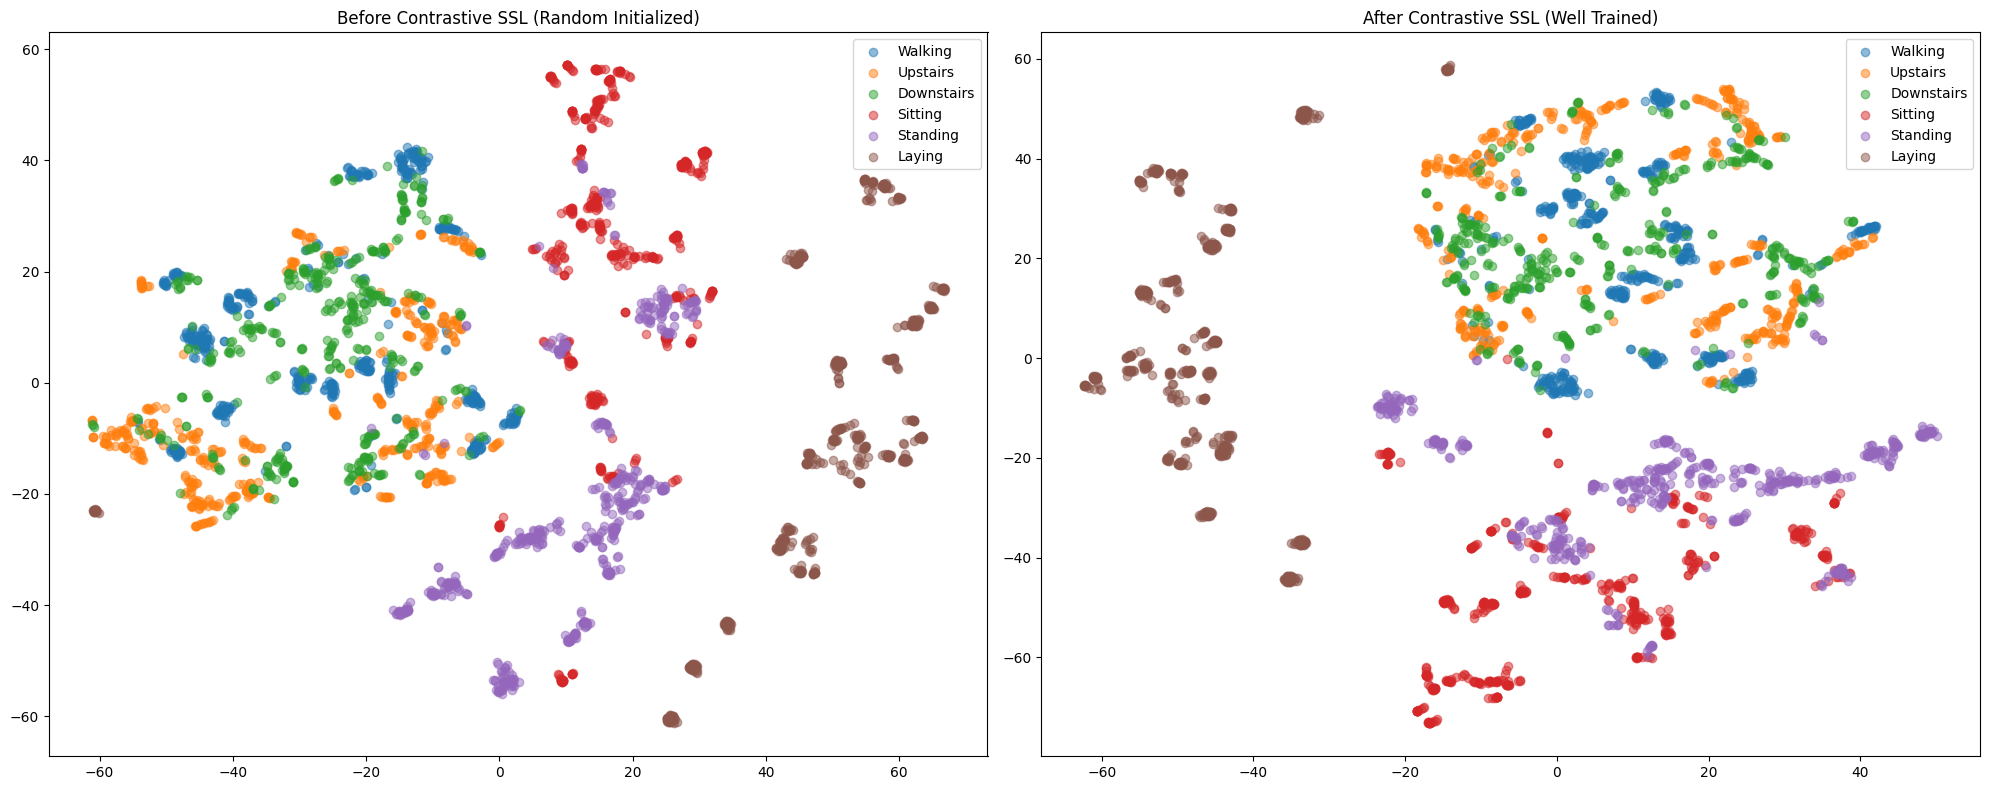

In [31]:
from sklearn.manifold import TSNE

# 테스트 데이터를 텐서 형태로 변환
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
# test_loader 정의
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 1. 시각화용 데이터 추출 함수 정의
def get_features_and_labels(target_encoder, loader):
    target_encoder.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            h = target_encoder(x_batch)
            all_features.append(h.cpu().numpy())
            all_labels.append(y_batch.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)

# 2. 특징 추출 (Before & After)
initial_encoder = CNN_Encoder().to(device)
features_before, labels_before = get_features_and_labels(initial_encoder, test_loader)
features_after, labels_after = get_features_and_labels(final_model.encoder, test_loader)

# 3. t-SNE 변환
tsne = TSNE(n_components=2, random_state=42)
proj_before = tsne.fit_transform(features_before)
proj_after = tsne.fit_transform(features_after)

# 4. 양옆에 그리기 (Subplots)
plt.figure(figsize=(20, 8))
class_names = ['Walking', 'Upstairs', 'Downstairs', 'Sitting', 'Standing', 'Laying']

# 왼쪽: 학습 전 (Before)
plt.subplot(1, 2, 1)
for i in range(6):
    idx = np.where(labels_before == i)
    plt.scatter(proj_before[idx, 0], proj_before[idx, 1], label=class_names[i], alpha=0.5)
plt.title("Before Contrastive SSL (Random Initialized)")
plt.legend()

# 오른쪽: 학습 후 (After)
plt.subplot(1, 2, 2)
for i in range(6):
    idx = np.where(labels_after == i)
    plt.scatter(proj_after[idx, 0], proj_after[idx, 1], label=class_names[i], alpha=0.5)
plt.title("After Contrastive SSL (Well Trained)")
plt.legend()

plt.tight_layout()
plt.show()

2. Fine-tuning : 실전 분류 학습 (Supervised Learning)

In [32]:
# 1. 사전 학습된 Encoder를 사용하여 최종 모델 생성
final_model = FineTuneCNN(encoder, num_classes=6).to(device)

# 2. 옵티마이저 및 손실 함수 설정
ft_optimizer = optim.Adam(final_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

ft_epochs = 50

In [35]:
for epoch in range(ft_epochs):
    final_model.train()
    train_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device).long()

        # 예측 및 손실 계산
        outputs = final_model(x_batch)
        loss = criterion(outputs, y_batch)

        ft_optimizer.zero_grad()
        loss.backward()
        ft_optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{ft_epochs}], Loss: {train_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")

Epoch [1/50], Loss: 1.5641, Acc: 49.37%
Epoch [2/50], Loss: 1.1505, Acc: 64.31%
Epoch [3/50], Loss: 0.8813, Acc: 72.03%
Epoch [4/50], Loss: 0.7032, Acc: 77.56%
Epoch [5/50], Loss: 0.5876, Acc: 80.51%
Epoch [6/50], Loss: 0.5090, Acc: 83.32%
Epoch [7/50], Loss: 0.4372, Acc: 85.92%
Epoch [8/50], Loss: 0.3891, Acc: 87.17%
Epoch [9/50], Loss: 0.3377, Acc: 89.55%
Epoch [10/50], Loss: 0.2995, Acc: 90.94%
Epoch [11/50], Loss: 0.2633, Acc: 91.89%
Epoch [12/50], Loss: 0.2392, Acc: 92.63%
Epoch [13/50], Loss: 0.2134, Acc: 93.12%
Epoch [14/50], Loss: 0.2006, Acc: 93.39%
Epoch [15/50], Loss: 0.1943, Acc: 93.73%
Epoch [16/50], Loss: 0.1858, Acc: 93.68%
Epoch [17/50], Loss: 0.1711, Acc: 94.34%
Epoch [18/50], Loss: 0.1640, Acc: 94.31%
Epoch [19/50], Loss: 0.1610, Acc: 94.67%
Epoch [20/50], Loss: 0.1603, Acc: 94.16%
Epoch [21/50], Loss: 0.1520, Acc: 94.67%
Epoch [22/50], Loss: 0.1486, Acc: 94.76%
Epoch [23/50], Loss: 0.1472, Acc: 94.74%
Epoch [24/50], Loss: 0.1405, Acc: 94.80%
Epoch [25/50], Loss: 0.13